In [4]:
import torch
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader , TensorDataset , random_split
from torch.optim import AdamW

import transformers
from transformers import AutoTokenizer ,AutoModel , AutoModelForTokenClassification ,\
DataCollatorForTokenClassification

from datasets import load_dataset

import emoji
import re
from collections import Counter
import unicodedata

from tqdm import tqdm
from torchmetrics import Accuracy
import numpy as np
import matplotlib.pyplot as plt

from evaluate import load

import warnings
warnings.filterwarnings('ignore')

In [5]:
dataset = load_dataset("Babelscape/wikineural")

In [6]:
dataset

DatasetDict({
    test_de: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 12372
    })
    test_en: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 11597
    })
    test_es: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 9618
    })
    test_fr: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 12678
    })
    test_it: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 11069
    })
    test_nl: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 10547
    })
    test_pl: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 13585
    })
    test_pt: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 10160
    })
    test_ru: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 11580
    })
    train_de: Dataset({
        features: ['tokens'

In [7]:
dataset['train_en']

Dataset({
    features: ['tokens', 'ner_tags', 'lang'],
    num_rows: 92720
})

In [8]:
dataset['train_en'][0]

{'tokens': ['This',
  'division',
  'also',
  'contains',
  'the',
  'Ventana',
  'Wilderness',
  ',',
  'home',
  'to',
  'the',
  'California',
  'condor',
  '.'],
 'ner_tags': [0, 0, 0, 0, 0, 5, 6, 0, 0, 0, 0, 5, 0, 0],
 'lang': 'en'}

In [9]:
dataset["train_en"].features

{'tokens': List(Value('string')),
 'ner_tags': List(Value('int64')),
 'lang': Value('string')}

In [10]:
for token , tag in zip(dataset['train_en'][0]['tokens'] ,dataset['train_en'][0]['ner_tags'] ):
    print('token:' , token ,'->', tag)

token: This -> 0
token: division -> 0
token: also -> 0
token: contains -> 0
token: the -> 0
token: Ventana -> 5
token: Wilderness -> 6
token: , -> 0
token: home -> 0
token: to -> 0
token: the -> 0
token: California -> 5
token: condor -> 0
token: . -> 0


In [11]:
ner_tags = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}

ner_tags_reversed = {v: k for k, v in ner_tags.items()}
ner_tags_reversed

{0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC',
 7: 'B-MISC',
 8: 'I-MISC'}

In [12]:
counter = Counter()
for sample in dataset['train_en']['ner_tags']:
    counter.update(sample)
counter

Counter({0: 1936105,
         5: 54902,
         1: 40264,
         7: 36163,
         8: 33391,
         2: 29466,
         3: 24225,
         4: 20396,
         6: 18767})

In [13]:
sum_tag = counter.total()
percent_list = []
for tag in counter.items():
    perc = round((tag[1] / sum_tag) * 100)
    counter[tag[0]] = perc
    percent_list.append(perc)



In [14]:
ner_tag_list = []
for tag_ner , tag_counter in zip(ner_tags.items() , counter.keys()):
    ner_tag_list.append(ner_tags_reversed[tag_counter])

ner_tag_list

['O', 'B-LOC', 'I-LOC', 'B-ORG', 'B-MISC', 'I-MISC', 'B-PER', 'I-PER', 'I-ORG']

In [15]:
ner_tags

{'O': 0,
 'B-PER': 1,
 'I-PER': 2,
 'B-ORG': 3,
 'I-ORG': 4,
 'B-LOC': 5,
 'I-LOC': 6,
 'B-MISC': 7,
 'I-MISC': 8}

In [16]:
counter

Counter({0: 88, 5: 3, 7: 2, 8: 2, 1: 2, 6: 1, 3: 1, 2: 1, 4: 1})

In [17]:
dataset['train_en']

Dataset({
    features: ['tokens', 'ner_tags', 'lang'],
    num_rows: 92720
})

In [18]:
lengths = [len(sample) for sample in dataset['train_en']['tokens']]

In [19]:
np.max(lengths) , np.min(lengths) ,  round(np.mean(lengths))

(165, 2, 24)

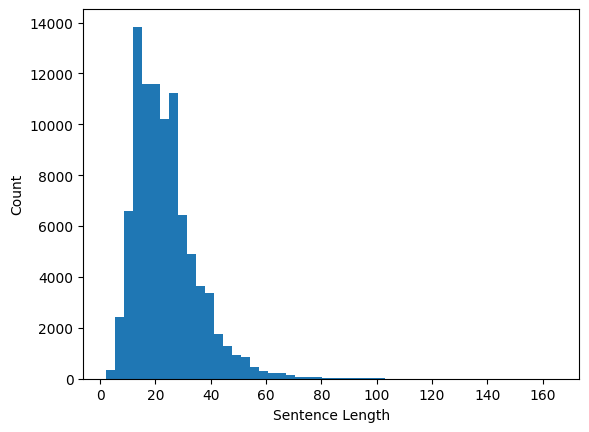

In [20]:
plt.hist(lengths, bins=50)
plt.xlabel("Sentence Length")
plt.ylabel("Count")
plt.show()

In [21]:
counter

Counter({0: 88, 5: 3, 7: 2, 8: 2, 1: 2, 6: 1, 3: 1, 2: 1, 4: 1})

In [22]:
counter.items()

dict_items([(0, 88), (5, 3), (6, 1), (3, 1), (7, 2), (8, 2), (1, 2), (2, 1), (4, 1)])

In [23]:
percent_list

[88, 3, 1, 1, 2, 2, 2, 1, 1]

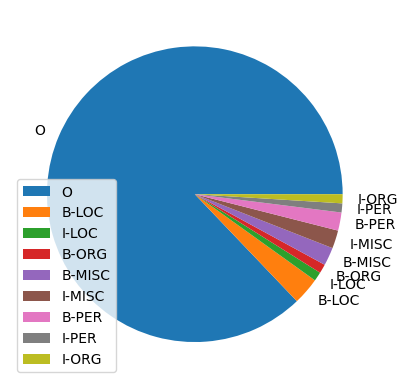

In [24]:
plt.pie(percent_list , labels= ner_tag_list )
plt.legend(ner_tag_list)
plt.savefig('pie.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')

In [26]:
encoding = tokenizer(
    dataset['train_en'][0]['tokens'],
    is_split_into_words= True
)
encoding

{'input_ids': [101, 1188, 2417, 1145, 2515, 1103, 159, 3452, 3906, 16436, 117, 1313, 1106, 1103, 1756, 14255, 8380, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [27]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'])

['[CLS]',
 'This',
 'division',
 'also',
 'contains',
 'the',
 'V',
 '##ent',
 '##ana',
 'Wilderness',
 ',',
 'home',
 'to',
 'the',
 'California',
 'con',
 '##dor',
 '.',
 '[SEP]']

In [28]:
encoding.word_ids()

[None, 0, 1, 2, 3, 4, 5, 5, 5, 6, 7, 8, 9, 10, 11, 12, 12, 13, None]

In [29]:
def tokenize_and_align_labels(example):
    encoding = tokenizer(example['tokens'] ,  truncation= True ,is_split_into_words=True)
    word_ids = encoding.word_ids()
    labels = []
    previous_word = None
    
    for word_id in word_ids:
        if word_id is None:
            labels.append(-100)
    
        elif word_id != previous_word:
            labels.append(example['ner_tags'][word_id])
        else:
            labels.append(-100)
        previous_word = word_id
        
    encoding["labels"] = labels
    return encoding

In [30]:
#tokenized_dataset_train.column_names

In [31]:
labels = tokenize_and_align_labels(dataset['train_en'][0])
labels

{'input_ids': [101, 1188, 2417, 1145, 2515, 1103, 159, 3452, 3906, 16436, 117, 1313, 1106, 1103, 1756, 14255, 8380, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 0, 0, 0, 0, 0, 5, -100, -100, 6, 0, 0, 0, 0, 5, 0, -100, 0, -100]}

In [32]:
data_collator = DataCollatorForTokenClassification(tokenizer = tokenizer)

In [33]:
data_collator

DataCollatorForTokenClassification(tokenizer=BertTokenizerFast(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}, padding=True, max_length=None, pad_to_multiple_of=None, label_pad_token_id=-100, r

In [34]:
help(DataCollatorForTokenClassification)

Help on class DataCollatorForTokenClassification in module transformers.data.data_collator:

class DataCollatorForTokenClassification(DataCollatorMixin)
 |  DataCollatorForTokenClassification(tokenizer: transformers.tokenization_utils_base.PreTrainedTokenizerBase, padding: Union[bool, str, transformers.utils.generic.PaddingStrategy] = True, max_length: Optional[int] = None, pad_to_multiple_of: Optional[int] = None, label_pad_token_id: int = -100, return_tensors: str = 'pt') -> None
 |  
 |  Data collator that will dynamically pad the inputs received, as well as the labels.
 |  
 |  Args:
 |      tokenizer ([`PreTrainedTokenizer`] or [`PreTrainedTokenizerFast`]):
 |          The tokenizer used for encoding the data.
 |      padding (`bool`, `str` or [`~utils.PaddingStrategy`], *optional*, defaults to `True`):
 |          Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
 |          among:
 |  
 |          - `True` or `'longest'` (d

In [35]:
x = tokenize_and_align_labels(dataset['train_en'][3])

In [36]:
len(x['input_ids']) , len(labels['input_ids']) # we need padding

(21, 19)

In [37]:
tokenized_dataset_train = dataset['train_en'].map(tokenize_and_align_labels ,
                                                  remove_columns= dataset['train_en'].column_names)

In [38]:
tokenized_dataset_test = dataset['test_en'].map(tokenize_and_align_labels , 
                                               remove_columns= dataset['test_en'].column_names)

In [39]:
tokenized_dataset_train

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 92720
})

In [40]:
tokenized_dataset_train[0]

{'input_ids': [101,
  1188,
  2417,
  1145,
  2515,
  1103,
  159,
  3452,
  3906,
  16436,
  117,
  1313,
  1106,
  1103,
  1756,
  14255,
  8380,
  119,
  102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [-100,
  0,
  0,
  0,
  0,
  0,
  5,
  -100,
  -100,
  6,
  0,
  0,
  0,
  0,
  5,
  0,
  -100,
  0,
  -100]}

In [41]:
tokenizer.convert_ids_to_tokens(tokenized_dataset_train[0]['input_ids'])

['[CLS]',
 'This',
 'division',
 'also',
 'contains',
 'the',
 'V',
 '##ent',
 '##ana',
 'Wilderness',
 ',',
 'home',
 'to',
 'the',
 'California',
 'con',
 '##dor',
 '.',
 '[SEP]']

In [42]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

In [43]:
data_collator

DataCollatorForTokenClassification(tokenizer=BertTokenizerFast(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}, padding=True, max_length=None, pad_to_multiple_of=None, label_pad_token_id=-100, r

In [44]:
train_loader = DataLoader(
    tokenized_dataset_train,
    batch_size=16,
    shuffle=True,
    collate_fn=data_collator
)

test_loader = DataLoader(
    tokenized_dataset_test,
    batch_size=32,
    shuffle=True,
    collate_fn=data_collator
)

In [45]:
batch = next(iter(train_loader))

In [46]:
batch

{'input_ids': tensor([[  101,  2189,  9455,  9041,  3592,  1826,  1511,  7824,  1944,  1114,
          6260,  1120,  9326,  6066,  2064,  1361,  1105,  1103, 11972,  2057,
          1111,  3458,  2064,  1361,   117,  4356,  6312,  1107,  1103,  1244,
          1311,   113,  2622,  1118,  6285, 16930,   114,  1120, 13631,  1715,
          2874,   117,  2680,  5451,  1120,  1672,  6260,  1107,  1103,  1331,
           119,   102,     0,     0,     0,     0,     0],
        [  101,  1130,  1346,  1347,  2424,   117,   161,   118, 11611,  3090,
          1115,  7124,  1125,  1126,  3682,  3213,  1104, 13936,  4184, 19911,
          1348,  4182,   119,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0],
        [  101,  1124,  1125,  2034,  2919,   170,  8004,  1947,  4041, 15341,

In [47]:
batch['input_ids'].shape

torch.Size([16, 57])

In [48]:
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=9
)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
model

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [50]:
sum(p.numel() for p in model.parameters()) /1_000_000

107.726601

In [51]:
outputs = model(**batch)

In [52]:
outputs.logits[0]

tensor([[ 4.0348e-02, -1.5922e-01, -1.9410e-01,  1.8631e-01,  4.0391e-01,
         -2.8186e-01, -1.7081e-02, -2.6898e-02,  7.0399e-02],
        [ 1.3870e-01, -2.6093e-01, -3.3122e-01,  4.1123e-01,  4.7798e-02,
          3.0944e-02, -7.1805e-02,  3.1167e-02,  6.7688e-03],
        [ 2.8808e-01, -5.2994e-01, -3.9224e-01, -8.9279e-02,  2.1439e-01,
         -2.0057e-01,  1.3375e-01, -1.1710e-02, -3.3856e-01],
        [ 1.2270e-01, -4.2124e-01, -3.8501e-01, -2.5791e-01,  4.2113e-02,
         -1.9506e-01,  3.5017e-01, -6.7977e-02, -8.5808e-05],
        [-3.1905e-02, -3.5851e-01, -3.4162e-01, -3.2343e-01, -1.8597e-01,
         -6.6333e-02,  1.6859e-01, -2.4221e-01, -2.2662e-01],
        [ 1.7903e-01, -3.3080e-01, -2.1918e-01, -1.7964e-01, -8.1025e-02,
         -1.8461e-01, -1.4371e-01, -2.8921e-01, -1.5424e-01],
        [ 2.0451e-02, -2.7860e-01, -4.0876e-01, -6.4856e-02, -1.7510e-01,
         -2.4347e-01,  2.2737e-01, -1.2055e-01, -1.4892e-01],
        [-1.6384e-01, -1.5026e-01, -7.2316e-01, 

In [53]:
outputs.logits.shape

torch.Size([16, 57, 9])

In [54]:
print(outputs.logits.shape , batch["labels"].shape)
print()
outputs.loss

torch.Size([16, 57, 9]) torch.Size([16, 57])



tensor(2.1542, grad_fn=<NllLossBackward0>)

In [139]:
optimizer = torch.optim.AdamW(model.parameters() , lr = 2e-5)

**seqeval**

In [56]:
##pip install seqeval

In [3]:
#pip install evaluate

In [127]:
metric = load("seqeval")

In [59]:
metric

EvaluationModule(name: "seqeval", module_type: "metric", features: {'predictions': List(Value('string')), 'references': List(Value('string'))}, usage: """
Produces labelling scores along with its sufficient statistics
from a source against one or more references.

Args:
    predictions: List of List of predicted labels (Estimated targets as returned by a tagger)
    references: List of List of reference labels (Ground truth (correct) target values)
    suffix: True if the IOB prefix is after type, False otherwise. default: False
    scheme: Specify target tagging scheme. Should be one of ["IOB1", "IOB2", "IOE1", "IOE2", "IOBES", "BILOU"].
        default: None
    mode: Whether to count correct entity labels with incorrect I/B tags as true positives or not.
        If you want to only count exact matches, pass mode="strict". default: None.
    sample_weight: Array-like of shape (n_samples,), weights for individual samples. default: None
    zero_division: Which value to substitute as a

In [60]:
predictions = [['O', 'O', 'B-MISC', 'I-MISC', 'I-MISC', 'I-MISC', 'O'], ['B-PER', 'I-PER', 'O']]
references = [['O', 'O', 'O', 'B-MISC', 'I-MISC', 'I-MISC', 'O'], ['B-PER', 'I-PER', 'O']]

In [61]:
metric.compute(predictions=predictions , references= references)

{'MISC': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 1},
 'PER': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'number': 1},
 'overall_precision': 0.5,
 'overall_recall': 0.5,
 'overall_f1': 0.5,
 'overall_accuracy': 0.8}

In [74]:
pred = outputs.logits[0].argmax(dim=-1)
labels = batch["labels"][0]
pred, labels

(tensor([4, 3, 0, 6, 6, 0, 6, 4, 6, 4, 0, 0, 0, 6, 6, 2, 6, 4, 4, 4, 4, 6, 7, 6,
         6, 5, 5, 4, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 1, 4, 6, 4, 6, 6, 6, 6, 0, 1,
         6, 4, 0, 0, 6, 6, 6, 6, 6]),
 tensor([-100,    0,    0, -100,    0,    0,    0,    5,    6,    0,    0,    0,
            5, -100, -100, -100,    0,    0,    0,    0,    0,    5, -100, -100,
            0,    0,    0,    0,    0,    5,    6,    0,    0,    0,    3, -100,
            0,    0,    5,    6,    6,    0,    3,    4,    0,    0,    0,    0,
            0,    0,    0, -100, -100, -100, -100, -100, -100]))

In [113]:
def clean_batch_labels(labels):
    ner_tags_reversed = {
    0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC',
 7: 'B-MISC',
 8: 'I-MISC'}
    new_labels = []
    for label in labels:
        if label != -100:
            new_labels.append(ner_tags_reversed[label])
    return new_labels

In [109]:
new_labels = clean_batch_labels(labels)

In [110]:
labels , new_labels

(array([-100,    0,    0, -100,    0,    0,    0,    5,    6,    0,    0,
           0,    5, -100, -100, -100,    0,    0,    0,    0,    0,    5,
        -100, -100,    0,    0,    0,    0,    0,    5,    6,    0,    0,
           0,    3, -100,    0,    0,    5,    6,    6,    0,    3,    4,
           0,    0,    0,    0,    0,    0,    0, -100, -100, -100, -100,
        -100, -100], dtype=int64),
 ['O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'I-LOC',
  'O',
  'O',
  'O',
  'B-LOC',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'I-LOC',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'O',
  'B-LOC',
  'I-LOC',
  'I-LOC',
  'O',
  'B-ORG',
  'I-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O'])

In [119]:
def postprocess(predictions, labels):
    ner_tags_reversed = {
    0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC',
 7: 'B-MISC',
 8: 'I-MISC'}
    true_predictions = []
    true_labels = []
    predictions = np.array(predictions)
    labels = np.array(labels)
    for pred, label in zip(predictions, labels):

        current_pred = []
        current_label = []

        for p, l in zip(pred, label):
            if l != -100:
                current_pred.append(ner_tags_reversed[p])
                current_label.append(ner_tags_reversed[l])

        true_predictions.append(current_pred)
        true_labels.append(current_label)

    return true_predictions, true_labels

In [120]:
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-06
    maximize: False
    weight_decay: 0.01
)

In [121]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [128]:
per , lab = postprocess(outputs.logits.argmax(dim = -1) , batch['labels'])

In [135]:
metric.add_batch(predictions = per , references=lab)

In [136]:
result = metric.compute()

In [137]:
result

{'LOC': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 10},
 'MISC': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 9},
 'ORG': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 3},
 'PER': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'number': 7},
 'overall_precision': 0.0,
 'overall_recall': 0.0,
 'overall_f1': 0.0,
 'overall_accuracy': 0.14095744680851063}

In [149]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [165]:
def train_one_epoch(model, train_loader, optimizer, device):

    model.train()

    loss_meter = AverageMeter()

    metric = load("seqeval")

    with tqdm(train_loader, unit="batch") as tepoch:

        for batch in tepoch:

            batch = {
                k: v#.to(device)
                for k, v in batch.items()
            }

            optimizer.zero_grad()

            outputs = model(**batch)

            loss = outputs.loss

            loss.backward()

            optimizer.step()

            preds = outputs.logits.argmax(dim=-1)

            true_preds, true_labels = postprocess(
                preds,
                batch["labels"]
            )

            metric.add_batch(
                predictions=true_preds,
                references=true_labels
            )

            loss_meter.update(
                loss.item(),
                batch["labels"].size(0)
            )

            tepoch.set_postfix(
                loss=f"{loss_meter.avg:.4f}"
            )

    results = metric.compute()

    return (
        model,
        loss_meter.avg,
        {"overall_precision" : results["overall_precision"],
        "overall_recall" : results["overall_recall"],
        "overall_f1" : results["overall_f1"]}
    )

In [166]:
def validation(model, valid_loader, device):

    model.eval()

    loss_meter = AverageMeter()

    metric = load("seqeval")

    with torch.no_grad():

        for batch in tqdm(valid_loader):

            batch = {
                k: v#.to(device)
                for k, v in batch.items()
            }

            outputs = model(**batch)

            loss = outputs.loss

            preds = outputs.logits.argmax(dim=-1)

            true_preds, true_labels = postprocess(
                preds.cpu(),
                batch["labels"].cpu()
            )

            metric.add_batch(
                predictions=true_preds,
                references=true_labels
            )

            loss_meter.update(
                loss.item(),
                batch["labels"].size(0)
            )

    results = metric.compute()

    return (
        loss_meter.avg,
        {"overall_precision" : results["overall_precision"],
        "overall_recall" : results["overall_recall"],
        "overall_f1" : results["overall_f1"]}
    )

In [167]:
loss_train_hist = []
loss_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0

In [168]:
num_epochs = 3

for epoch in range(num_epochs):
  # Train
  model, loss_train, result = train_one_epoch(model, 
                                                 train_loader, 
                                                 optimizer,
                                                 epoch
                                                  )
  # Validation
  loss_valid, result = validation(model,
                                     test_loader)
  
  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)
  
  if loss_valid < best_loss_valid:
    torch.save(model, f'NER_Model.pt')
    best_loss_valid = loss_valid
    print('Model Saved!')

  print(f'Valid: Loss = {loss_valid:.4}')
  print()

  epoch_counter += 1

  2%|▏         | 95/5795 [30:37<30:37:05, 19.34s/batch, loss=0.4711]


KeyboardInterrupt: 